# Netflix Success Prediction — EDA & Hypothesis Testing

**Research questions:**
- Which genres tend to have higher IMDB ratings?
- Do TV shows perform better than movies?
- Does release year affect content success?
- How does country of origin influence ratings?
- Is popularity (vote count) correlated with perceived quality (IMDB rating)?

---

## 1. Imports & Setup

In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

sns.set(style="whitegrid")

## 2. Data Collection & Loading

In [200]:
#data loading
netflix = pd.read_csv('../data/raw/netflix_titles.csv')
imdb = pd.read_csv('../data/raw/Netflix TV Shows and Movies.csv')

print(netflix.shape)
print(netflix.columns)
print(imdb.shape)
print(imdb.columns)

(8807, 12)
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')
(5283, 11)
Index(['index', 'id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'imdb_id', 'imdb_score', 'imdb_votes'],
      dtype='str')


### Dataset Previews

In [201]:
netflix.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


In [202]:
imdb.head(2)

,index,id,title,type,description,release_year,age_certification,runtime,imdb_id,imdb_score,imdb_votes
0,0,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,113,tt0075314,8.3,795222.0
1,1,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,tt0071853,8.2,530877.0


## 3. Data Merging

Both datasets are merged on the 'title' column (normalized to lowercase and stripped of whitespace) using an **inner join**, retaining only titles that appear in both datasets.

In [203]:
# merge
netflix['title'] = netflix['title'].str.lower().str.strip()
imdb['title'] = imdb['title'].str.lower().str.strip()

df = pd.merge(netflix, imdb, on='title', how='inner')

print("Merged shape:", df.shape)
df.head(3)

Merged shape: (3960, 22)


,show_id,type_x,title,director,cast,country,date_added,release_year_x,rating,duration,...,index,id,type_y,description_y,release_year_y,age_certification,runtime,imdb_id,imdb_score,imdb_votes
0,s1,Movie,dick johnson is dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,...,3241,tm845484,MOVIE,"With this inventive portrait, director Kirsten...",2020,PG-13,89,tt11394180,7.4,6390.0
1,s3,TV Show,ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,...,4811,ts304058,SHOW,"Mehdi, a qualified robber, and Liana, an appre...",2021,TV-MA,46,tt13278100,7.0,2460.0
2,s4,TV Show,jailbirds new orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,...,5190,ts308053,SHOW,"Feuds, flirtations and toilet talk go down amo...",2021,TV-MA,41,tt15320436,6.6,205.0


### Inspecting Merged Columns

In [204]:
df.columns

Index(['show_id', 'type_x', 'title', 'director', 'cast', 'country',
       'date_added', 'release_year_x', 'rating', 'duration', 'listed_in',
       'description_x', 'index', 'id', 'type_y', 'description_y',
       'release_year_y', 'age_certification', 'runtime', 'imdb_id',
       'imdb_score', 'imdb_votes'],
      dtype='str')

## 4. Data Cleaning & Preprocessing

- Convert `imdb_score` and `imdb_votes` to numeric, dropping rows where either is missing.
- Fill missing 'country' values with `'Unknown'`.

In [205]:
#numeric conversion and cleaning missing values
df['imdb_score'] = pd.to_numeric(df['imdb_score'], errors='coerce')
df['imdb_votes'] = pd.to_numeric(df['imdb_votes'], errors='coerce')
df['release_year'] = pd.to_numeric(df['release_year_x'], errors='coerce')

df = df.dropna(subset=['imdb_score', 'imdb_votes'])
df['country'] = df['country'].fillna('Unknown')

print(df.shape)
df.isnull().sum()

(3955, 23)


show_id                 0
type_x                  0
title                   0
director             1429
cast                  362
country                 0
date_added              0
release_year_x          0
rating                  0
duration                1
listed_in               0
description_x           0
index                   0
id                      0
type_y                  0
description_y           3
release_year_y          0
age_certification    1718
runtime                 0
imdb_id                 0
imdb_score              0
imdb_votes              0
release_year            0
dtype: int64

### Column Renaming & Duration Extraction

In [206]:
#rename and extract duration
df = df.rename(columns={
    'type_x': 'type',
    'description_x': 'description',
    'rating': 'content_rating'
})

df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(float)

## 5. Feature Engineering — Composite Score

A **composite success score** is computed as a weighted combination of two normalized components:

| Component | Weight | Rationale |
|---|---|---|
| IMDB score (normalized) | 60% | Perceived quality |
| Log-transformed vote count (normalized) | 40% | Popularity / reach |

Both components are scaled to [0, 1] via Min-Max normalization before combining. The log transform on vote count reduces the effect of extreme outliers.

In [207]:
#calculate composite score
scaler = MinMaxScaler()

df['imdb_score_norm'] = scaler.fit_transform(df[['imdb_score']])
df['imdb_votes_log'] = np.log1p(df['imdb_votes'])
df['imdb_votes_norm'] = scaler.fit_transform(df[['imdb_votes_log']])
df['composite_score'] = 0.6 * df['imdb_score_norm'] + 0.4 * df['imdb_votes_norm']

df[['title', 'imdb_score', 'imdb_votes', 'composite_score']].head(10)

,title,imdb_score,imdb_votes,composite_score
0,dick johnson is dead,7.4,6390.0,0.654152
1,ganglands,7.0,2460.0,0.594799
2,jailbirds new orleans,6.6,205.0,0.487913
3,kota factory,9.3,66985.0,0.868073
4,midnight mass,7.7,102321.0,0.762749
5,my little pony: a new generation,6.8,3468.0,0.590676
6,sankofa,7.0,678.0,0.554692
7,the great british baking show,8.6,9564.0,0.755599
8,the starling,6.3,11733.0,0.591594
9,"vendetta: truth, lies and the mafia",6.7,232.0,0.499157


### Final Dataset Structure

In [208]:
# select and reorder relevant columns
df = df[['title', 'type', 'country', 'release_year', 'duration', 'duration_int', 
         'listed_in', 'content_rating', 'description', 'imdb_score', 'imdb_votes', 
         'imdb_score_norm', 'imdb_votes_log', 'imdb_votes_norm', 'composite_score']]

print(df.shape)
df.head()

(3955, 15)


,title,type,country,release_year,duration,duration_int,listed_in,content_rating,description,imdb_score,imdb_votes,imdb_score_norm,imdb_votes_log,imdb_votes_norm,composite_score
0,dick johnson is dead,Movie,United States,2020,90 min,90.0,Documentaries,PG-13,"As her father nears the end of his life, filmm...",7.4,6390.0,0.728395,8.762646,0.542787,0.654152
1,ganglands,TV Show,Unknown,2021,1 Season,1.0,"Crime TV Shows, International TV Shows, TV Act...",TV-MA,To protect his family from a powerful drug lor...,7.0,2460.0,0.679012,7.808323,0.468478,0.594799
2,jailbirds new orleans,TV Show,Unknown,2021,1 Season,1.0,"Docuseries, Reality TV",TV-MA,"Feuds, flirtations and toilet talk go down amo...",6.6,205.0,0.629630,5.327876,0.275339,0.487913
3,kota factory,TV Show,India,2021,2 Seasons,2.0,"International TV Shows, Romantic TV Shows, TV ...",TV-MA,In a city of coaching centers known to train I...,9.3,66985.0,0.962963,11.112239,0.725737,0.868073
4,midnight mass,TV Show,Unknown,2021,1 Season,1.0,"TV Dramas, TV Horror, TV Mysteries",TV-MA,The arrival of a charismatic young priest brin...,7.7,102321.0,0.765432,11.535880,0.758724,0.762749


### Missing Value Summary

In [209]:
print(df.shape)
df.isnull().sum()

(3955, 15)


title              0
type               0
country            0
release_year       0
duration           1
duration_int       1
listed_in          0
content_rating     0
description        0
imdb_score         0
imdb_votes         0
imdb_score_norm    0
imdb_votes_log     0
imdb_votes_norm    0
composite_score    0
dtype: int64

## 6. Exploratory Data Analysis (EDA)

### 6.1 Score Distributions

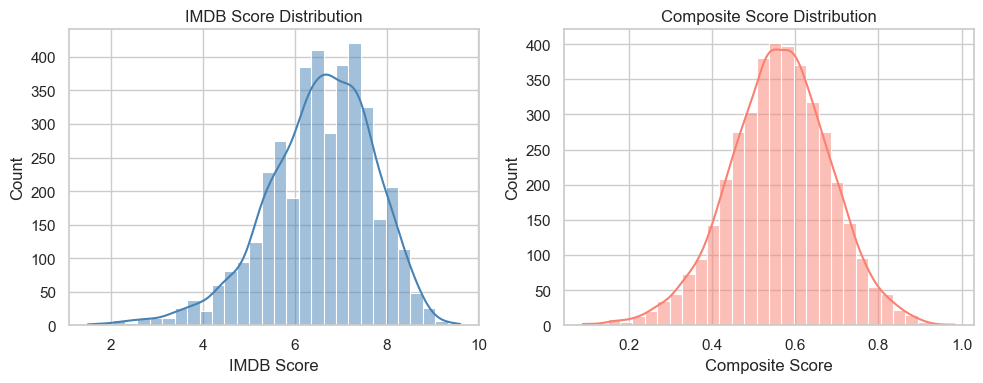

In [210]:
#imdb score distribution
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['imdb_score'], bins=30, kde=True, color='steelblue')
plt.title('IMDB Score Distribution')
plt.xlabel('IMDB Score')

plt.subplot(1, 2, 2)
sns.histplot(df['composite_score'], bins=30, kde=True, color='salmon')
plt.title('Composite Score Distribution')
plt.xlabel('Composite Score')

plt.tight_layout()
plt.show()

### 6.2 Movie vs TV Show Comparison

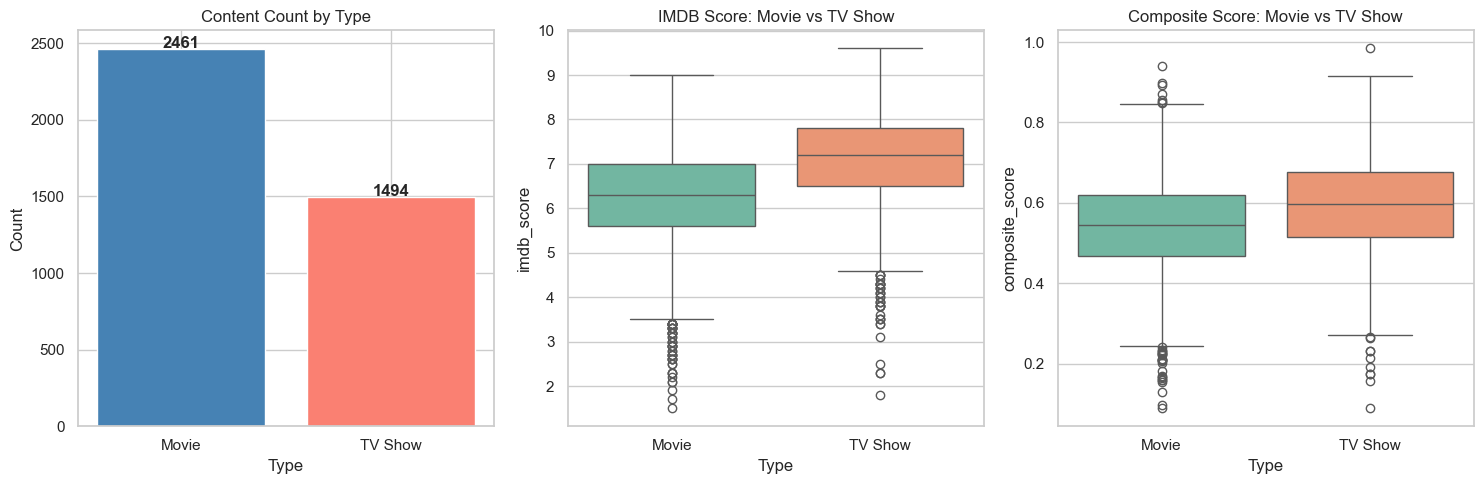

In [211]:
# content type count and score comparison: Movie vs TV Show
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Count by type
type_counts = df['type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values, color=['steelblue', 'salmon'], edgecolor='white')
axes[0].set_title('Content Count by Type')
axes[0].set_xlabel('Type')
axes[0].set_ylabel('Count')
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# IMDB score by type
sns.boxplot(data=df, x='type', y='imdb_score', hue='type', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('IMDB Score: Movie vs TV Show')
axes[1].set_xlabel('Type')

# Composite score by type
sns.boxplot(data=df, x='type', y='composite_score', hue='type', palette='Set2', legend=False, ax=axes[2])
axes[2].set_title('Composite Score: Movie vs TV Show')
axes[2].set_xlabel('Type')

plt.tight_layout()
plt.show()

### 6.3 Genre Analysis

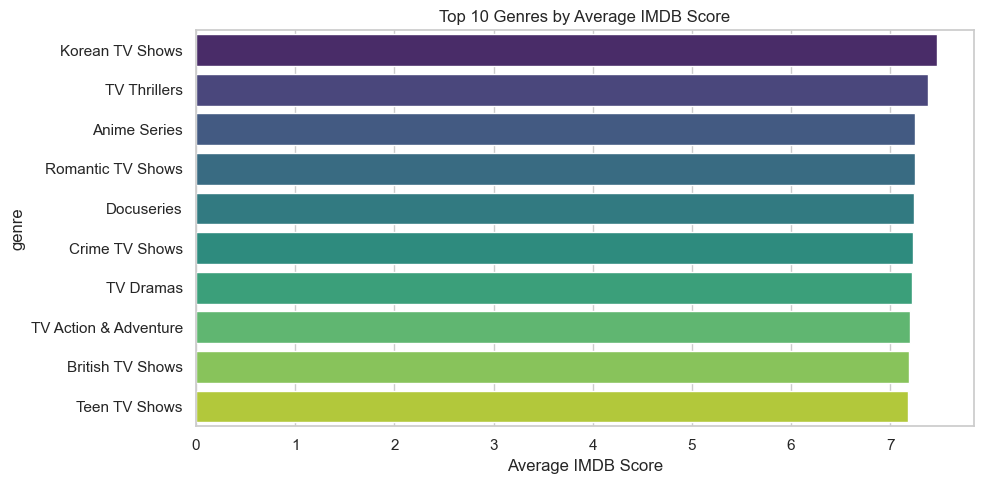

In [212]:
# top 10 genres by average IMDB score
genre_df = df.copy()
genre_df['genre'] = genre_df['listed_in'].str.split(', ')
genre_df = genre_df.explode('genre')

top_genres = genre_df.groupby('genre')['imdb_score'].agg(['mean', 'count'])
top_genres = top_genres[top_genres['count'] >= 30].sort_values('mean', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_genres['mean'], y=top_genres.index, hue=top_genres.index, palette='viridis', legend=False)
plt.title('Top 10 Genres by Average IMDB Score')
plt.xlabel('Average IMDB Score')
plt.tight_layout()
plt.show()

### 6.4 Release Year Trends

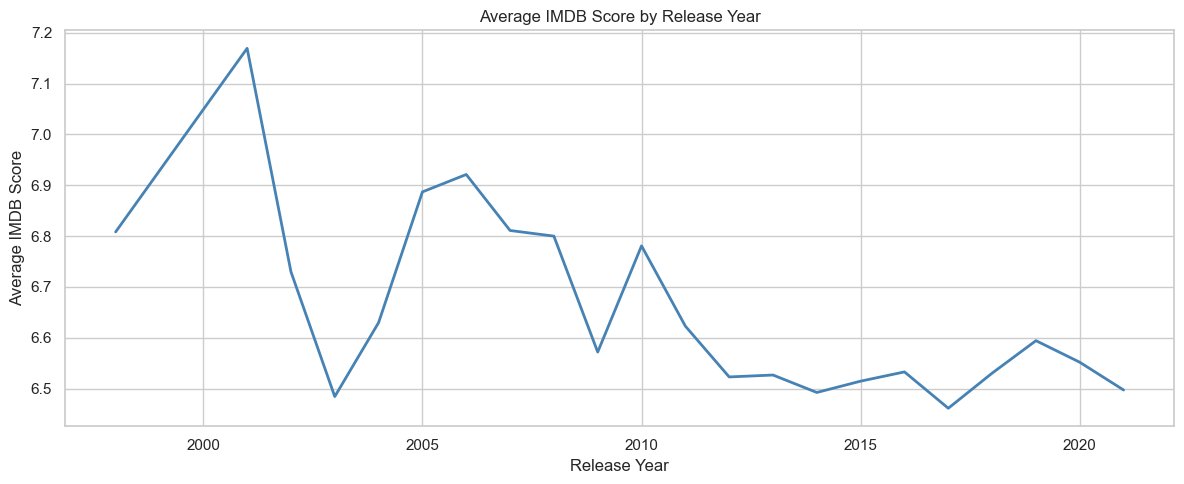

In [213]:
# average IMDB score by release year
yearly = df.groupby('release_year')['imdb_score'].agg(['mean', 'count']).reset_index()
yearly = yearly[yearly['count'] >= 10]  # only years with at least 10 titles

plt.figure(figsize=(12, 5))
sns.lineplot(data=yearly, x='release_year', y='mean', color='steelblue', linewidth=2)
plt.title('Average IMDB Score by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Average IMDB Score')
plt.tight_layout()
plt.show()

### 6.5 Country Analysis

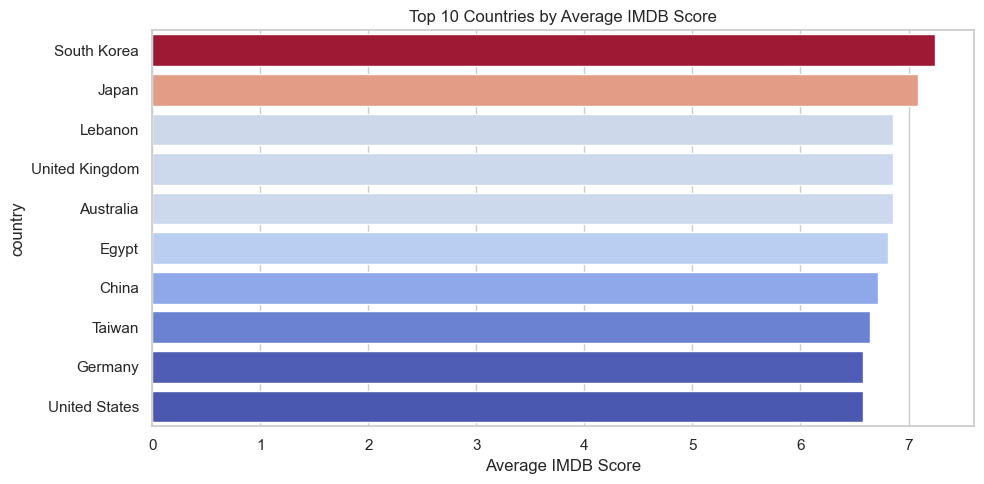

In [214]:
# top 10 countries by average IMDB score (excluding Unknown)
country_df = df[df['country'] != 'Unknown'].copy()
country_df['country'] = country_df['country'].str.split(', ')
country_df = country_df.explode('country')
country_df = country_df[country_df['country'] != 'Unknown']

top_countries = country_df.groupby('country')['imdb_score'].agg(['mean', 'count']).reset_index()
top_countries = top_countries[top_countries['count'] >= 20].sort_values('mean', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_countries, x='mean', y='country', hue='mean', palette='coolwarm', legend=False)
plt.title('Top 10 Countries by Average IMDB Score')
plt.xlabel('Average IMDB Score')
plt.tight_layout()
plt.show()

### 6.6 Duration vs IMDB Score

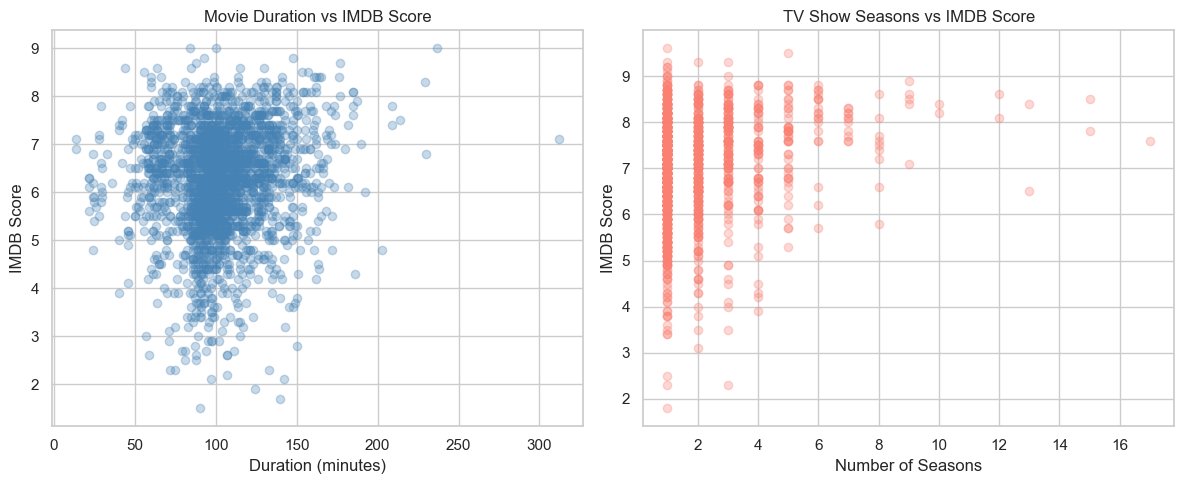

In [215]:
#duration vs score
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Movies — duration in minutes
movies = df[df['type'] == 'Movie']
axes[0].scatter(movies['duration_int'], movies['imdb_score'], alpha=0.3, color='steelblue')
axes[0].set_title('Movie Duration vs IMDB Score')
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_ylabel('IMDB Score')

# TV Shows — number of seasons
shows = df[df['type'] == 'TV Show']
axes[1].scatter(shows['duration_int'], shows['imdb_score'], alpha=0.3, color='salmon')
axes[1].set_title('TV Show Seasons vs IMDB Score')
axes[1].set_xlabel('Number of Seasons')
axes[1].set_ylabel('IMDB Score')

plt.tight_layout()
plt.show()

### 6.7 Correlation Heatmap

Pairwise Pearson correlations between the key numeric variables: IMDB score, vote count, release year, duration, and composite score.

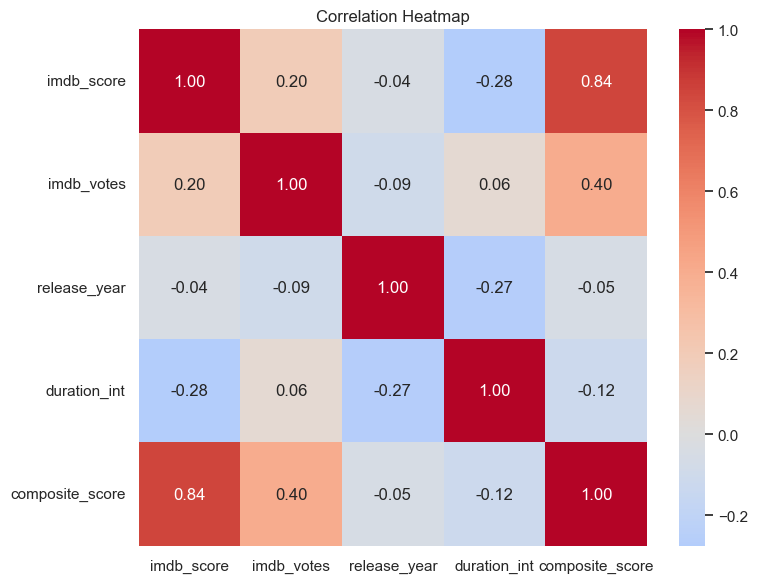

In [216]:
#correlation heatmap
corr_cols = ['imdb_score', 'imdb_votes', 'release_year', 'duration_int', 'composite_score']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 7. Hypothesis Testing

Statistical tests to formally evaluate the research questions. Significance level: **α = 0.05**.

| # | Hypothesis | Test |
|---|---|---|
| 7.1 | TV shows and movies differ in mean IMDB score | Independent two-sample t-test |
| 7.2 | Mean IMDB score differs across genres | One-way ANOVA |
| 7.3 | Release year is correlated with IMDB score | Pearson & Spearman correlation |
| 7.4 | Vote count (popularity) is correlated with IMDB score (quality) | Pearson & Spearman correlation |

---

### 7.1 Two-Sample T-test: Movies vs TV Shows

**H₀:** Movies and TV shows have the same mean IMDB score.  
**H₁:** The mean IMDB scores differ between movies and TV shows.

In [217]:
from scipy import stats

movies_scores = df[df['type'] == 'Movie']['imdb_score'].dropna()
shows_scores = df[df['type'] == 'TV Show']['imdb_score'].dropna()

t_stat, p_value = stats.ttest_ind(movies_scores, shows_scores)

print(f"Movie mean: {movies_scores.mean():.2f}")
print(f"TV Show mean: {shows_scores.mean():.2f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("There is a significant difference between movies and TV shows in terms of IMDb scores.")
else:
    print("There is no significant difference.")

Movie mean: 6.25
TV Show mean: 7.05
P-value: 0.0000
There is a significant difference between movies and TV shows in terms of IMDb scores.


### 7.2 One-Way ANOVA: Differences Across Genres

**H₀:** All genres share the same mean IMDB score.  
**H₁:** At least one genre differs significantly in mean IMDB score.

Genres with fewer than 30 titles are excluded to ensure reliable group estimates.

In [218]:
from scipy.stats import f_oneway

genre_df = df.copy()
genre_df['genre'] = genre_df['listed_in'].str.split(', ')
genre_df = genre_df.explode('genre')

valid_genres = genre_df.groupby('genre').filter(lambda x: len(x) >= 30)
genre_groups = [group['imdb_score'].dropna().values for _, group in valid_genres.groupby('genre')]

f_stat, p_value = f_oneway(*genre_groups)

print(f"Number of genres: {len(genre_groups)}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("There is a significant difference between genres in terms of IMDb scores.")
else:
    print("There is no significant difference between genres in terms of IMDb scores.")

Number of genres: 34
P-value: 0.0000
There is a significant difference between genres in terms of IMDb scores.


### 7.2b Post-hoc Analysis: Tukey HSD

ANOVA showed that at least one genre differs significantly. Tukey's HSD identifies **which pairs** of genres differ from each other.

Only the most impactful significant pairs are shown (sorted by mean difference).

In [219]:
import warnings
from scipy.integrate import IntegrationWarning
from statsmodels.stats.multicomp import pairwise_tukeyhsd

with warnings.catch_warnings():
    warnings.simplefilter("ignore", IntegrationWarning)
    tukey = pairwise_tukeyhsd(
        endog=valid_genres['imdb_score'].dropna(),
        groups=valid_genres.loc[valid_genres['imdb_score'].notna(), 'genre'],
        alpha=0.05
    )

tukey_df = pd.DataFrame(
    data=tukey._results_table.data[1:],
    columns=tukey._results_table.data[0]
)
tukey_df['meandiff'] = tukey_df['meandiff'].astype(float)
tukey_df['p-adj'] = tukey_df['p-adj'].astype(float)

significant = tukey_df[tukey_df['reject'] == True].copy()
significant = significant.sort_values('meandiff', ascending=False)

print(f"Total genre pairs tested: {len(tukey_df)}")
print(f"Significantly different pairs: {len(significant)}")
print("\nTop 10 pairs with largest mean IMDB score difference:")
significant[['group1', 'group2', 'meandiff', 'p-adj']].head(10)

Total genre pairs tested: 561
Significantly different pairs: 296

Top 10 pairs with largest mean IMDB score difference:


,group1,group2,meandiff,p-adj
265,Horror Movies,Korean TV Shows,2.0945,0.0
282,Horror Movies,TV Thrillers,2.0083,0.0
270,Horror Movies,Romantic TV Shows,1.8737,0.0
278,Horror Movies,TV Dramas,1.8436,0.0
276,Horror Movies,TV Action & Adventure,1.8203,0.0
283,Horror Movies,Teen TV Shows,1.7996,0.0
280,Horror Movies,TV Mysteries,1.7785,0.0
272,Horror Movies,Science & Nature TV,1.7689,0.0
263,Horror Movies,International TV Shows,1.7596,0.0
281,Horror Movies,TV Sci-Fi & Fantasy,1.7528,0.0


### 7.3 Correlation: Release Year vs IMDB Score

**H₀:** There is no correlation between release year and IMDB score (ρ = 0).  
**H₁:** Release year and IMDB score are significantly correlated.

Both Pearson (linear) and Spearman (rank-based, robust to non-linearity) correlations are reported. With large samples (n ≈ 4000), Pearson can reach statistical significance even for negligible effect sizes — so both the p-value and the magnitude of r are considered when interpreting the result.

In [220]:
from scipy.stats import pearsonr, spearmanr

clean = df[['release_year', 'imdb_score']].dropna()

pearson_r, pearson_p = pearsonr(clean['release_year'], clean['imdb_score'])
spearman_r, spearman_p = spearmanr(clean['release_year'], clean['imdb_score'])

print(f"n = {len(clean)}")
print(f"Pearson  r = {pearson_r:.3f},  p = {pearson_p:.4f}")
print(f"Spearman r = {spearman_r:.3f},  p = {spearman_p:.4f}")
print()

if pearson_p < 0.05 and spearman_p < 0.05:
    print("Both tests are significant — release year and IMDB score are correlated.")
elif pearson_p < 0.05 and spearman_p >= 0.05:
    print(f"Pearson is statistically significant (p={pearson_p:.4f}), "
          f"but Spearman is not (p={spearman_p:.4f}).")
    print(f"Pearson r = {pearson_r:.3f} is negligible in magnitude.")
    print("The correlation is very weak and not practically meaningful.".format(len(clean)))
    print("Conclusion: No practically meaningful correlation between release year and IMDB score.")
else:
    print("No statistically significant correlation between release year and IMDB score.")

n = 3955
Pearson  r = -0.039,  p = 0.0145
Spearman r = -0.018,  p = 0.2549

Pearson is statistically significant (p=0.0145), but Spearman is not (p=0.2549).
Pearson r = -0.039 is negligible in magnitude.
The correlation is very weak and not practically meaningful.
Conclusion: No practically meaningful correlation between release year and IMDB score.


### 7.4 Correlation: Vote Count vs IMDB Score

**H₀:** There is no correlation between vote count (popularity) and IMDB score (quality).  
**H₁:** Vote count and IMDB score are significantly correlated.

This directly tests the research question: *Is popularity correlated with perceived quality?*

n = 3955
Pearson r: 0.195, p-value: 0.0000
Spearman r: 0.239, p-value: 0.0000
There is a statistically significant correlation between vote count and IMDb score.


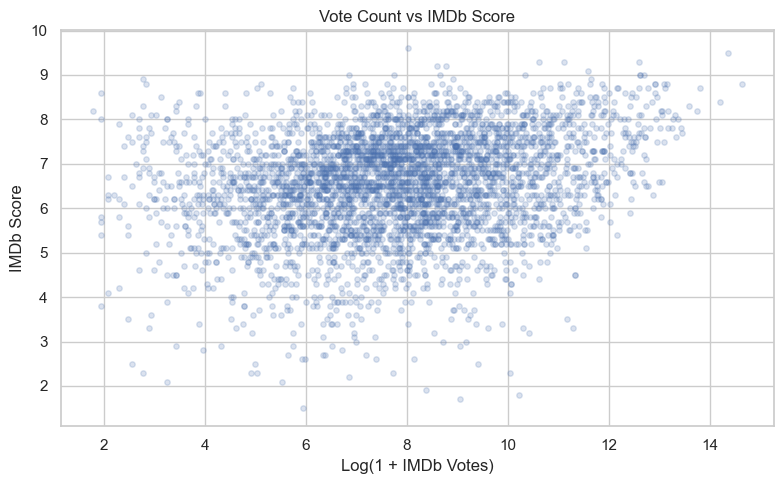

In [221]:
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import numpy as np

clean_votes = df[['imdb_votes', 'imdb_score']].dropna()

pearson_r, pearson_p = pearsonr(clean_votes['imdb_votes'], clean_votes['imdb_score'])
spearman_r, spearman_p = spearmanr(clean_votes['imdb_votes'], clean_votes['imdb_score'])

print(f"n = {len(clean_votes)}")
print(f"Pearson r: {pearson_r:.3f}, p-value: {pearson_p:.4f}")
print(f"Spearman r: {spearman_r:.3f}, p-value: {spearman_p:.4f}")

if pearson_p < 0.05 and spearman_p < 0.05:
    print("There is a statistically significant correlation between vote count and IMDb score.")
else:
    print("There is no statistically significant correlation between vote count and IMDb score.")

# Scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(np.log1p(clean_votes['imdb_votes']), clean_votes['imdb_score'], alpha=0.2, s=15)
plt.xlabel('Log(1 + IMDb Votes)')
plt.ylabel('IMDb Score')
plt.title('Vote Count vs IMDb Score')
plt.tight_layout()
plt.show()

## 8. Final Insights

- **TV shows vs movies:** TV shows tend to have higher IMDb scores on average (7.05 vs 6.25, p ≈ 0).

- **Genre differences:** Genre significantly affects ratings (ANOVA p ≈ 0). Horror Movies are the lowest-rated genre, with differences of up to ~2 points compared to some TV genres.

- **Release year:** No meaningful effect. Pearson r = −0.039 is negligible and Spearman is not significant (p = 0.255). The correlation is very weak and not practically meaningful.

- **Country of origin:** Descriptively, South Korea, Japan, and the UK tend to score higher than average. No formal hypothesis test was run for this question.

- **Popularity vs quality:** Significant positive correlation (Pearson r = 0.195, Spearman r = 0.239, both p ≈ 0). More popular titles tend to be better rated, though the effect is weak.


## 9. Machine Learning

Two tasks are modeled:
- **Regression** — predict IMDB score
- **Classification** — predict whether a title is successful (IMDB score >= 7.0)

Models used: Linear/Logistic Regression (baseline) and Random Forest.  
Features: content type, release year, log vote count, runtime, content rating, and top 15 genres as binary columns.

### 9.1 Feature Engineering

In [222]:
from sklearn.preprocessing import LabelEncoder

ml = df.copy()

ml['is_tvshow'] = (ml['type'] == 'TV Show').astype(int)
ml['log_votes'] = np.log1p(ml['imdb_votes'])

le = LabelEncoder()
ml['rating_enc'] = le.fit_transform(ml['content_rating'].fillna('Unknown'))

genre_exploded = ml['listed_in'].str.split(', ').explode()
top_genres = genre_exploded.value_counts().head(15).index.tolist()
for g in top_genres:
    ml[f'genre_{g}'] = ml['listed_in'].str.contains(g, regex=False).astype(int)

genre_cols = [f'genre_{g}' for g in top_genres]
feature_cols = ['is_tvshow', 'release_year', 'log_votes', 'duration_int', 'rating_enc'] + genre_cols

ml = ml.dropna(subset=feature_cols + ['imdb_score'])

X = ml[feature_cols]
y_reg = ml['imdb_score']
y_clf = (ml['imdb_score'] >= 7.0).astype(int)

print('Samples:', len(ml))
print('Features:', len(feature_cols))
print('Success rate (score >= 7.0):', round(y_clf.mean(), 3))


Samples: 3954
Features: 20
Success rate (score >= 7.0): 0.395


### 9.2 Regression -- Predicting IMDB Score

Linear Regression serves as the baseline. Random Forest captures non-linear relationships.  
Evaluation metrics: RMSE and R2.

In [223]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_rmse = mean_squared_error(y_test, lr_pred) ** 0.5
lr_r2 = r2_score(y_test, lr_pred)

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)
rf_pred = rf_reg.predict(X_test)
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

print('              RMSE     R2')
print(f'Linear Reg    {lr_rmse:.3f}    {lr_r2:.3f}')
print(f'Random Forest {rf_rmse:.3f}    {rf_r2:.3f}')


              RMSE     R2
Linear Reg    1.004    0.302
Random Forest 0.941    0.386


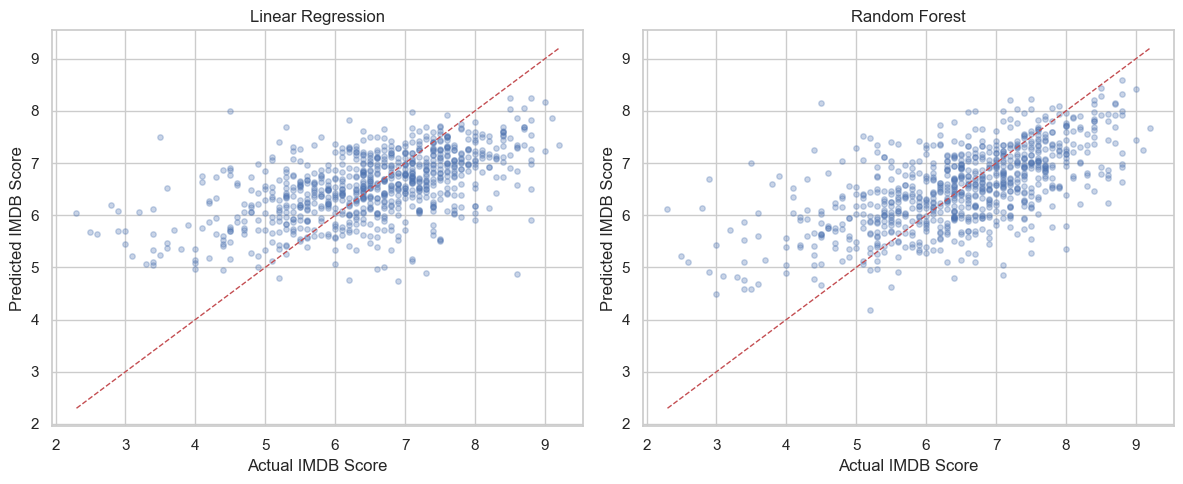

In [224]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(axes, [lr_pred, rf_pred], ['Linear Regression', 'Random Forest']):
    ax.scatter(y_test, preds, alpha=0.3, s=15)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1)
    ax.set_xlabel('Actual IMDB Score')
    ax.set_ylabel('Predicted IMDB Score')
    ax.set_title(title)

plt.tight_layout()
plt.show()


### 9.3 Classification - Predicting Success (IMDB Score >= 7.0)

A title is labeled **successful** if its IMDB score is 7.0 or above. 
Logistic Regression serves as the baseline. Random Forest is compared against it.  
Evaluation: accuracy, F1 score, confusion matrix, and ROC curve.

In [225]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, roc_auc_score

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# scale for logistic regression
scaler_clf = StandardScaler()
X_train_scaled = scaler_clf.fit_transform(X_train_c)
X_test_scaled = scaler_clf.transform(X_test_c)

log_reg = LogisticRegression(max_iter=2000, random_state=42)
log_reg.fit(X_train_scaled, y_train_c)
log_pred = log_reg.predict(X_test_scaled)

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_c, y_train_c)
rf_clf_pred = rf_clf.predict(X_test_c)

print("                    Accuracy    F1")
print(f"Logistic Regression  {accuracy_score(y_test_c, log_pred):.3f}       {f1_score(y_test_c, log_pred):.3f}")
print(f"Random Forest        {accuracy_score(y_test_c, rf_clf_pred):.3f}       {f1_score(y_test_c, rf_clf_pred):.3f}")


                    Accuracy    F1
Logistic Regression  0.765       0.695
Random Forest        0.770       0.697


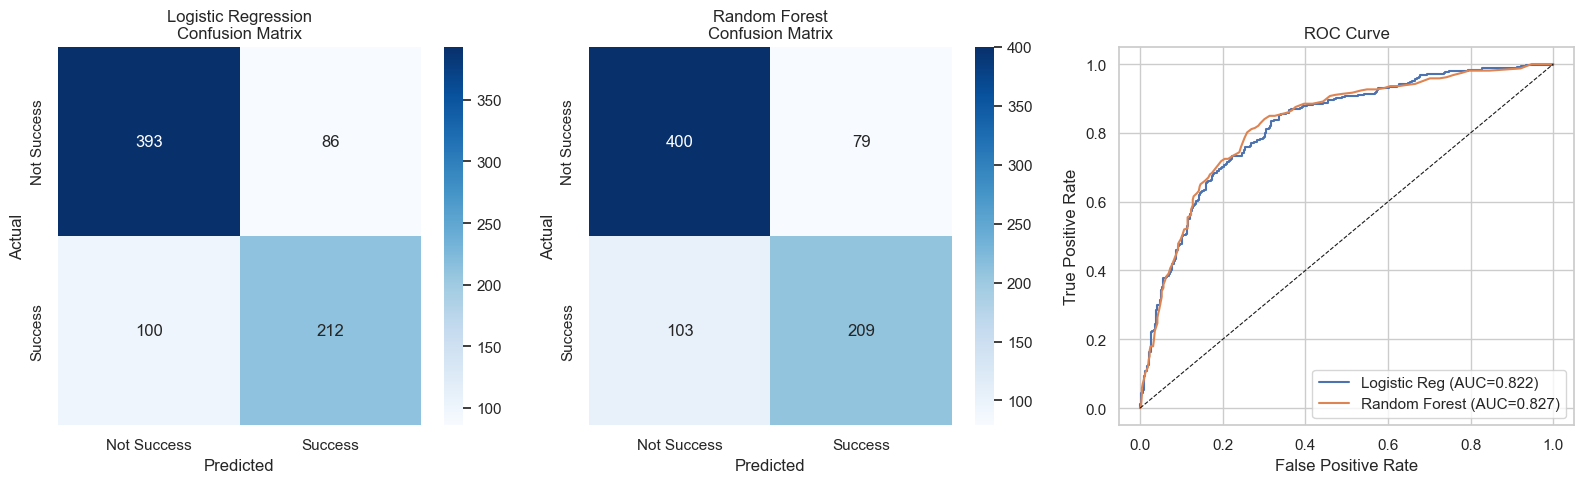

In [226]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, preds, title in zip(axes[:2],
                             [log_pred, rf_clf_pred],
                             ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test_c, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Success', 'Success'],
                yticklabels=['Not Success', 'Success'])
    ax.set_title(f'{title}\nConfusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

log_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
rf_proba = rf_clf.predict_proba(X_test_c)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test_c, log_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test_c, rf_proba)

axes[2].plot(fpr_lr, tpr_lr, label=f'Logistic Reg (AUC={roc_auc_score(y_test_c, log_proba):.3f})')
axes[2].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test_c, rf_proba):.3f})')
axes[2].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve')
axes[2].legend()

plt.tight_layout()
plt.show()


### 9.4 Feature Importance (Random Forest)

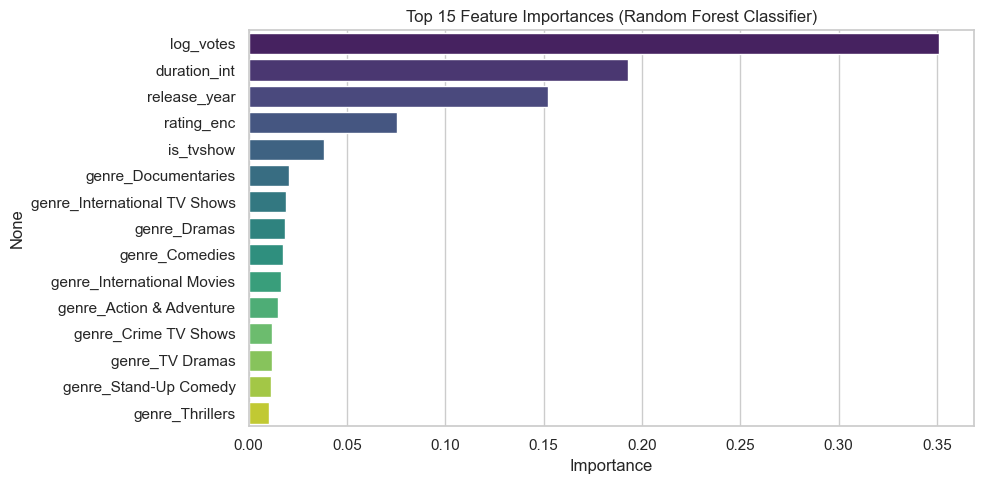

In [227]:
importances = rf_clf.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, hue=feat_imp.index, palette='viridis', legend=False)
plt.title('Top 15 Feature Importances (Random Forest Classifier)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


### 9.5 Decision Tree & Gradient Boosting

Two additional models are evaluated for both regression and classification tasks:
- **Decision Tree** — simple, interpretable baseline tree model
- **Gradient Boosting (XGBoost)** — ensemble of trees trained sequentially to minimize residual error


In [228]:
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from xgboost import XGBRegressor, XGBClassifier

# Regression
dt_reg = DecisionTreeRegressor(max_depth=6, random_state=42)
dt_reg.fit(X_train, y_train)
dt_reg_pred = dt_reg.predict(X_test)
dt_reg_rmse = mean_squared_error(y_test, dt_reg_pred) ** 0.5
dt_reg_r2 = r2_score(y_test, dt_reg_pred)

xgb_reg = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42, verbosity=0)
xgb_reg.fit(X_train, y_train)
xgb_reg_pred = xgb_reg.predict(X_test)
xgb_reg_rmse = mean_squared_error(y_test, xgb_reg_pred) ** 0.5
xgb_reg_r2 = r2_score(y_test, xgb_reg_pred)

print('Regression Results')
print('                RMSE     R2')
print(f'Linear Reg      {lr_rmse:.3f}    {lr_r2:.3f}')
print(f'Decision Tree   {dt_reg_rmse:.3f}    {dt_reg_r2:.3f}')
print(f'Random Forest   {rf_rmse:.3f}    {rf_r2:.3f}')
print(f'XGBoost         {xgb_reg_rmse:.3f}    {xgb_reg_r2:.3f}')


Regression Results
                RMSE     R2
Linear Reg      1.004    0.302
Decision Tree   1.013    0.288
Random Forest   0.941    0.386
XGBoost         0.943    0.384


In [229]:
# Classification
dt_clf = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_clf.fit(X_train_c, y_train_c)
dt_clf_pred = dt_clf.predict(X_test_c)

xgb_clf = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1,
                         random_state=42, verbosity=0, eval_metric='logloss')
xgb_clf.fit(X_train_c, y_train_c)
xgb_clf_pred = xgb_clf.predict(X_test_c)

print('Classification Results')
print('                    Accuracy    F1')
print(f'Logistic Reg         {accuracy_score(y_test_c, log_pred):.3f}       {f1_score(y_test_c, log_pred):.3f}')
print(f'Decision Tree        {accuracy_score(y_test_c, dt_clf_pred):.3f}       {f1_score(y_test_c, dt_clf_pred):.3f}')
print(f'Random Forest        {accuracy_score(y_test_c, rf_clf_pred):.3f}       {f1_score(y_test_c, rf_clf_pred):.3f}')
print(f'XGBoost              {accuracy_score(y_test_c, xgb_clf_pred):.3f}       {f1_score(y_test_c, xgb_clf_pred):.3f}')


Classification Results
                    Accuracy    F1
Logistic Reg         0.765       0.695
Decision Tree        0.743       0.633
Random Forest        0.770       0.697
XGBoost              0.798       0.732


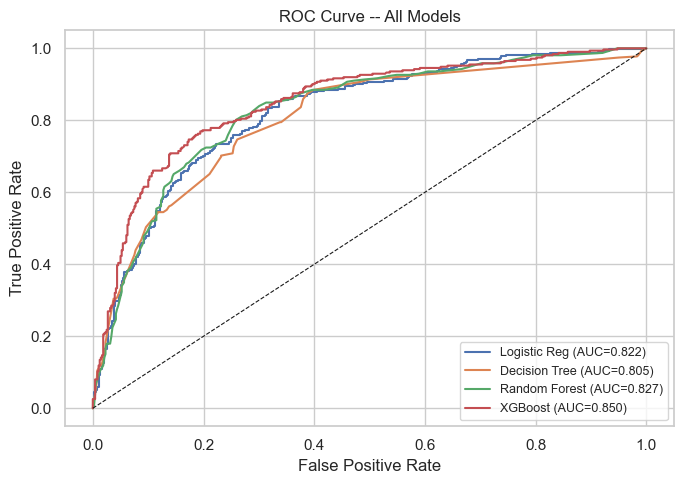

In [230]:
# ROC curve — all 4 classifiers
xgb_proba = xgb_clf.predict_proba(X_test_c)[:, 1]
dt_proba = dt_clf.predict_proba(X_test_c)[:, 1]

plt.figure(figsize=(7, 5))
for proba, label in [
    (log_proba, f'Logistic Reg (AUC={roc_auc_score(y_test_c, log_proba):.3f})'),
    (dt_proba,  f'Decision Tree (AUC={roc_auc_score(y_test_c, dt_proba):.3f})'),
    (rf_proba,  f'Random Forest (AUC={roc_auc_score(y_test_c, rf_proba):.3f})'),
    (xgb_proba, f'XGBoost (AUC={roc_auc_score(y_test_c, xgb_proba):.3f})'),
]:
    fpr, tpr, _ = roc_curve(y_test_c, proba)
    plt.plot(fpr, tpr, label=label)

plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve -- All Models')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


### 9.6 Extended Features: Director, Cast & Country

Three additional features are engineered using Leave-One-Out (LOO) encoding to avoid data leakage:
- **director_loo**: for each title, the mean IMDB score of all *other* titles by the same director
- **cast_loo**: for each title, the mean LOO score across all cast members in the title
- **country**: primary country encoded as top-10 countries + Other (binary dummies)

LOO encoding prevents leakage by excluding the current sample when computing the group mean.

In [231]:
# reload director and cast from raw data
netflix_raw = pd.read_csv('../data/raw/netflix_titles.csv')
netflix_raw['title'] = netflix_raw['title'].str.lower().str.strip()
netflix_raw = netflix_raw[['title', 'director', 'cast']].drop_duplicates('title')
ml2 = ml.merge(netflix_raw, on='title', how='left').reset_index(drop=True)

global_mean = ml2['imdb_score'].mean()

# Leave-One-Out encoding helper
def loo_encode(series, target, global_mean):
    group_sum = series.map(target.groupby(series).sum())
    group_cnt = series.map(target.groupby(series).count())
    loo = (group_sum - target) / (group_cnt - 1)
    return loo.where(group_cnt > 1, global_mean).fillna(global_mean)

# director LOO
ml2['director_loo'] = loo_encode(ml2['director'].fillna('Unknown'), ml2['imdb_score'], global_mean)

# cast LOO — explode by actor, LOO per actor, then average per title
cast_exp = ml2[['title', 'cast', 'imdb_score']].copy()
cast_exp['cast'] = cast_exp['cast'].fillna('')
cast_exp = cast_exp.assign(actor=cast_exp['cast'].str.split(', ')).explode('actor')
cast_exp = cast_exp[cast_exp['actor'] != ''].reset_index(drop=True)
cast_exp['actor_loo'] = loo_encode(cast_exp['actor'], cast_exp['imdb_score'], global_mean)
title_cast_loo = cast_exp.groupby('title')['actor_loo'].mean()
ml2['cast_loo'] = ml2['title'].map(title_cast_loo).fillna(global_mean)

# primary country — top 10 + Other
ml2['primary_country'] = ml2['country'].str.split(', ').str[0]
top_countries_ml = ml2['primary_country'].value_counts().head(10).index.tolist()
ml2['primary_country'] = ml2['primary_country'].apply(lambda x: x if x in top_countries_ml else 'Other')
country_dummies = pd.get_dummies(ml2['primary_country'], prefix='country').astype(int)
ml2 = pd.concat([ml2, country_dummies], axis=1)
country_cols = list(country_dummies.columns)

ext_feature_cols = feature_cols + ['director_loo', 'cast_loo'] + country_cols
X_ext = ml2[ext_feature_cols]
y_clf_ext = (ml2['imdb_score'] >= 7.0).astype(int)
print('Extended feature count:', len(ext_feature_cols))
print('LOO features: director_loo, cast_loo +'  , len(country_cols), 'country columns')


Extended feature count: 33
LOO features: director_loo, cast_loo + 11 country columns


In [232]:
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_ext, y_clf_ext, test_size=0.2, random_state=42, stratify=y_clf_ext)

X_train_e_scaled = scaler_clf.fit_transform(X_train_e)
X_test_e_scaled = scaler_clf.transform(X_test_e)

log_ext = LogisticRegression(max_iter=2000, random_state=42)
log_ext.fit(X_train_e_scaled, y_train_e)

dt_ext = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_ext.fit(X_train_e, y_train_e)

rf_ext = RandomForestClassifier(n_estimators=100, random_state=42)
rf_ext.fit(X_train_e, y_train_e)

xgb_ext = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1,
                          random_state=42, verbosity=0, eval_metric='logloss')
xgb_ext.fit(X_train_e, y_train_e)

print('Classification Results -- Extended Features')
print('                    Accuracy    F1')
for name, model, Xte in [
    ('Logistic Reg    ', log_ext, X_test_e_scaled),
    ('Decision Tree   ', dt_ext,  X_test_e),
    ('Random Forest   ', rf_ext,  X_test_e),
    ('XGBoost         ', xgb_ext, X_test_e),
]:
    pred = model.predict(Xte)
    print(f'{name}  {accuracy_score(y_test_e, pred):.3f}       {f1_score(y_test_e, pred):.3f}')


Classification Results -- Extended Features
                    Accuracy    F1
Logistic Reg      0.765       0.703
Decision Tree     0.837       0.784
Random Forest     0.867       0.821
XGBoost           0.882       0.844


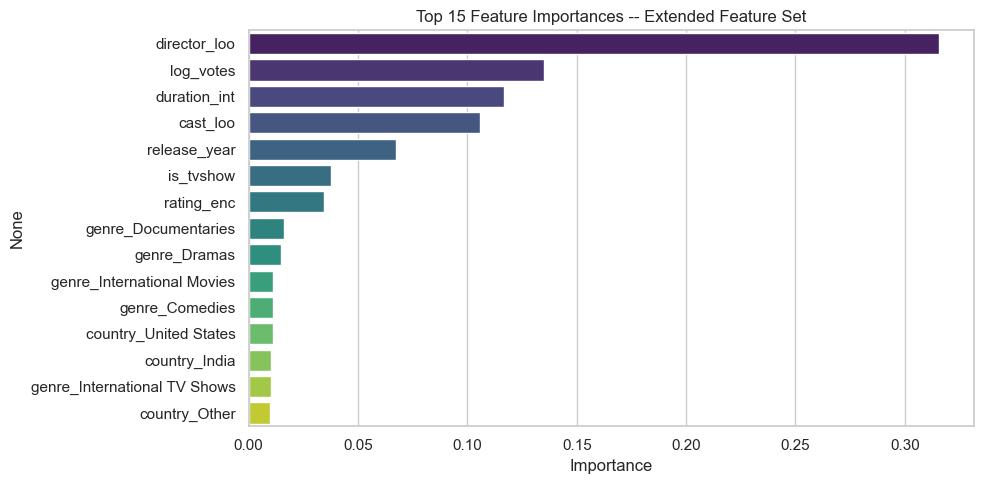

In [233]:
ext_imp = pd.Series(rf_ext.feature_importances_, index=ext_feature_cols)
ext_imp = ext_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=ext_imp.values, y=ext_imp.index, hue=ext_imp.index, palette='viridis', legend=False)
plt.title('Top 15 Feature Importances -- Extended Feature Set')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


### 9.7 ML Insights

**Baseline features** (type, release year, log votes, runtime, content rating, top 15 genres):
- Regression: Random Forest performs best (RMSE: 0.941, R2: 0.386), slightly ahead of XGBoost (RMSE: 0.943). Decision Tree is the weakest model. The low R2 values across all models suggest metadata alone explains only part of the variance in IMDB scores.
- Classification: XGBoost achieves the best results (Accuracy: 0.798, F1: 0.732), followed by Random Forest (F1: 0.697). Decision Tree is again the weakest (F1: 0.633).

**Extended features** (+ director LOO, cast LOO, country):
- Adding director and cast LOO-encoded scores alongside country significantly improves all models. XGBoost reaches F1: 0.844 and Random Forest reaches F1: 0.821, showing that who makes the content is a strong predictor of its quality.
- LOO (Leave-One-Out) encoding was used to prevent data leakage: each sample's group mean is computed excluding that sample itself.

**Feature importance** (from Random Forest on extended features): director_loo and cast_loo rank among the top features alongside log_votes, confirming that production team reputation is as informative as popularity.
